In [5]:
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix




In [6]:

# Step 2: Load dataset
data = datasets.load_breast_cancer()
X = data.data
y = data.target

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Base Model Accuracy: 0.956140350877193


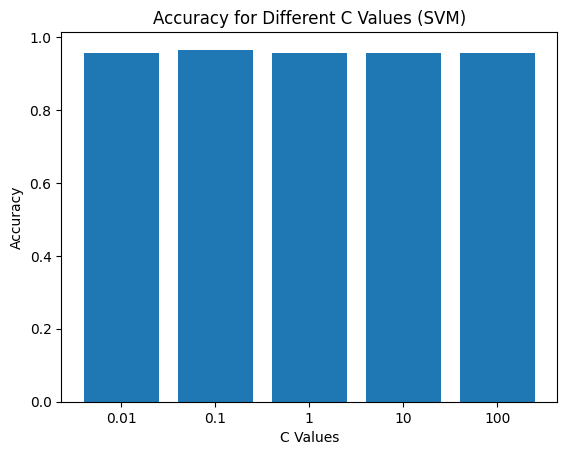

In [7]:


model = SVC(kernel='linear')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Base Model Accuracy:", accuracy)


# Step 5: Accuracy Curve (C values)
C_values = [0.01, 0.1, 1, 10, 100]
accuracies = []

for c in C_values:
    temp_model = SVC(kernel='linear', C=c)
    temp_model.fit(X_train, y_train)
    y_pred_temp = temp_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred_temp)
    accuracies.append(acc)

# Bar Chart (Easy Visualization)
plt.figure()
plt.bar([str(c) for c in C_values], accuracies)
plt.xlabel('C Values')
plt.ylabel('Accuracy')
plt.title('Accuracy for Different C Values (SVM)')
plt.show()





Confusion Matrix:
 [[39  4]
 [ 1 70]]


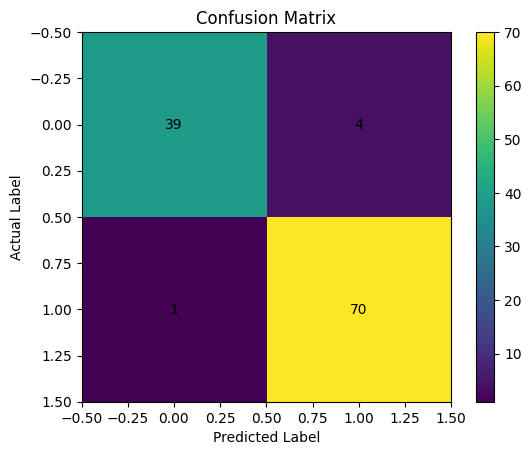

In [8]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Plot Confusion Matrix (Simple)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Add numbers inside matrix
for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.colorbar()
plt.show()